# **Bike Sharing Systems - Demand Forecasting with Linear Regression**

With the data cleaned and explored, the next step is building models to predict
how many bikes will be rented in a given hour. We use linear regression as our
modeling approach, starting simple and progressively adding complexity to
improve performance.

The pipeline works through five stages:

1. Two baseline models: one using weather data only, one using all available features
2. A polynomial model to capture non-linear relationships
3. An interaction model to capture how variables influence each other
4. Three regularized models (Ridge, Lasso, Elastic Net) with tuned penalties
5. A side-by-side comparison of all models, with a Q-Q diagnostic for the winner

Because all numeric features have been normalized to the same [0, 1] scale,
model coefficients can be compared directly as a measure of how much each
variable contributes to the prediction.

## **Setup**

In [9]:
install.packages("tidymodels")
install.packages("glmnet")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [10]:
library(tidymodels)
library(tidyverse)
library(glmnet)

## **Load Data**

We load the normalized Seoul bike sharing dataset from the wrangling step.
Two columns are dropped before modeling: `DATE`, which at this granularity
acts as little more than a row index, and `YES`, the single-value
`FUNCTIONING_DAY` dummy that carries no useful information after
missing value removal.

In [11]:
bike_sharing_df <- read_csv(
  "seoul_bike_sharing_converted_normalized.csv",
  show_col_types = FALSE
) %>%
  select(-DATE, -YES)

glimpse(bike_sharing_df)

Rows: 8,465
Columns: 39
$ RENTED_BIKE_COUNT     <dbl> 0.07090602, 0.05683737, 0.04811480, 0.02954418, …
$ TEMPERATURE           <dbl> 0.2202797, 0.2150350, 0.2062937, 0.2027972, 0.20…
$ HUMIDITY              <dbl> 0.3775510, 0.3877551, 0.3979592, 0.4081633, 0.36…
$ WIND_SPEED            <dbl> 0.29729730, 0.10810811, 0.13513514, 0.12162162, …
$ VISIBILITY            <dbl> 1.0000000, 1.0000000, 1.0000000, 1.0000000, 1.00…
$ DEW_POINT_TEMPERATURE <dbl> 0.2249135, 0.2249135, 0.2231834, 0.2249135, 0.20…
$ SOLAR_RADIATION       <dbl> 0.000000000, 0.000000000, 0.000000000, 0.0000000…
$ RAINFALL              <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ SNOWFALL              <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ WINTER                <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ SPRING                <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ SUMMER                <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ AUTUMN        

## **Train / Test Split**

We split the data 75/25: three quarters for training the models, one quarter
held back for testing. The seed fixes the random split so results are
reproducible if the notebook is re-run.

In [12]:
set.seed(1234)
data_split <- initial_split(bike_sharing_df, prop = 3/4)
train_data <- training(data_split)
test_data  <- testing(data_split)

cat("Training rows:", nrow(train_data), "\n")
cat("Testing rows: ", nrow(test_data),  "\n")

Training rows: 6348 
Testing rows:  2117 


## **Shared Utilities**

To keep things clean and consistent, we define a helper function that
evaluates any fitted model against the test set and records its R-squared
and RMSE. Every model in this notebook runs through the same function,
so results are stored in a single list and the best model is identified
automatically at the end.

In [13]:
# Initialise empty results store
all_results <- list()

# Helper: evaluate a fitted model, store metrics and predictions
evaluate_model <- function(model, label, test_data) {
  preds <- test_data %>%
    select(RENTED_BIKE_COUNT) %>%
    rename(truth = RENTED_BIKE_COUNT) %>%
    mutate(prediction = pmax(0, predict(model, test_data)$.pred))

  r2   <- rsq(preds,  truth = truth, estimate = prediction)$.estimate
  rmse <- rmse(preds, truth = truth, estimate = prediction)$.estimate

  cat(label, "- R2:", round(r2, 4), " RMSE:", round(rmse, 4), "\n")

  list(label = label, r2 = r2, rmse = rmse, predictions = preds)
}

# Model specification
lm_spec <- linear_reg() %>%
  set_engine("lm") %>%
  set_mode("regression")

## **Baseline Model 1 - Weather Variables Only**

The first model uses only the eight weather variables as predictors. This
gives us a sense of how much demand can be explained by weather conditions
alone, before we bring in any information about time of day or season.

In [14]:
lm_model_weather <- lm_spec %>%
  fit(
    RENTED_BIKE_COUNT ~ TEMPERATURE + HUMIDITY + WIND_SPEED +
      VISIBILITY + DEW_POINT_TEMPERATURE + SOLAR_RADIATION +
      RAINFALL + SNOWFALL,
    data = train_data
  )

summary(lm_model_weather$fit)

all_results[["weather"]] <- evaluate_model(lm_model_weather, "Weather Only", test_data)


Call:
stats::lm(formula = RENTED_BIKE_COUNT ~ TEMPERATURE + HUMIDITY + 
    WIND_SPEED + VISIBILITY + DEW_POINT_TEMPERATURE + SOLAR_RADIATION + 
    RAINFALL + SNOWFALL, data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.37942 -0.08273 -0.01612  0.05869  0.65554 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)            0.043532   0.016341   2.664  0.00774 ** 
TEMPERATURE            0.675221   0.073623   9.171  < 2e-16 ***
HUMIDITY              -0.258408   0.035676  -7.243  4.9e-13 ***
WIND_SPEED             0.113806   0.013551   8.399  < 2e-16 ***
VISIBILITY             0.003533   0.006994   0.505  0.61351    
DEW_POINT_TEMPERATURE -0.089172   0.078455  -1.137  0.25575    
SOLAR_RADIATION       -0.125170   0.009760 -12.824  < 2e-16 ***
RAINFALL              -0.496346   0.051392  -9.658  < 2e-16 ***
SNOWFALL               0.089414   0.037023   2.415  0.01576 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 

Weather Only - R2: 0.4415  RMSE: 0.1333 


## **Baseline Model 2 - All Features**

The second baseline throws everything in: weather variables plus all the
hour-of-day, season, and holiday indicators. This is a straightforward
way to see how much the datetime context improves on weather alone.

In [15]:
lm_model_all <- lm_spec %>%
  fit(RENTED_BIKE_COUNT ~ ., data = train_data)

summary(lm_model_all$fit)

all_results[["all"]] <- evaluate_model(lm_model_all, "All Features", test_data)


Call:
stats::lm(formula = RENTED_BIKE_COUNT ~ ., data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.39433 -0.06161 -0.00206  0.05614  0.50103 

Coefficients: (3 not defined because of singularities)
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)            0.1543567  0.0179483   8.600  < 2e-16 ***
TEMPERATURE            0.2202189  0.0596874   3.690 0.000227 ***
HUMIDITY              -0.2495020  0.0279944  -8.913  < 2e-16 ***
WIND_SPEED             0.0089795  0.0113323   0.792 0.428169    
VISIBILITY             0.0061541  0.0057013   1.079 0.280439    
DEW_POINT_TEMPERATURE  0.1683701  0.0622873   2.703 0.006888 ** 
SOLAR_RADIATION        0.0779070  0.0116674   6.677 2.64e-11 ***
RAINFALL              -0.5809335  0.0403140 -14.410  < 2e-16 ***
SNOWFALL               0.0734309  0.0291216   2.522 0.011709 *  
WINTER                -0.1010128  0.0057089 -17.694  < 2e-16 ***
SPRING                -0.0471677  0.0040294 -11.706  < 2e-16 *

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `prediction = pmax(0, predict(model, test_data)$.pred)`.
Caused by warning in `predict.lm()`:
! prediction from rank-deficient fit; consider predict(., rankdeficient="NA")”


All Features - R2: 0.6893  RMSE: 0.0999 


## **Variable Importance - Coefficient Chart**

Because all numeric features are on the same [0, 1] scale, we can read
the model coefficients as a rough ranking of variable importance. Larger
absolute values mean that variable moves the prediction more. Blue bars
push the count up, red bars push it down.

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_bar()`).”


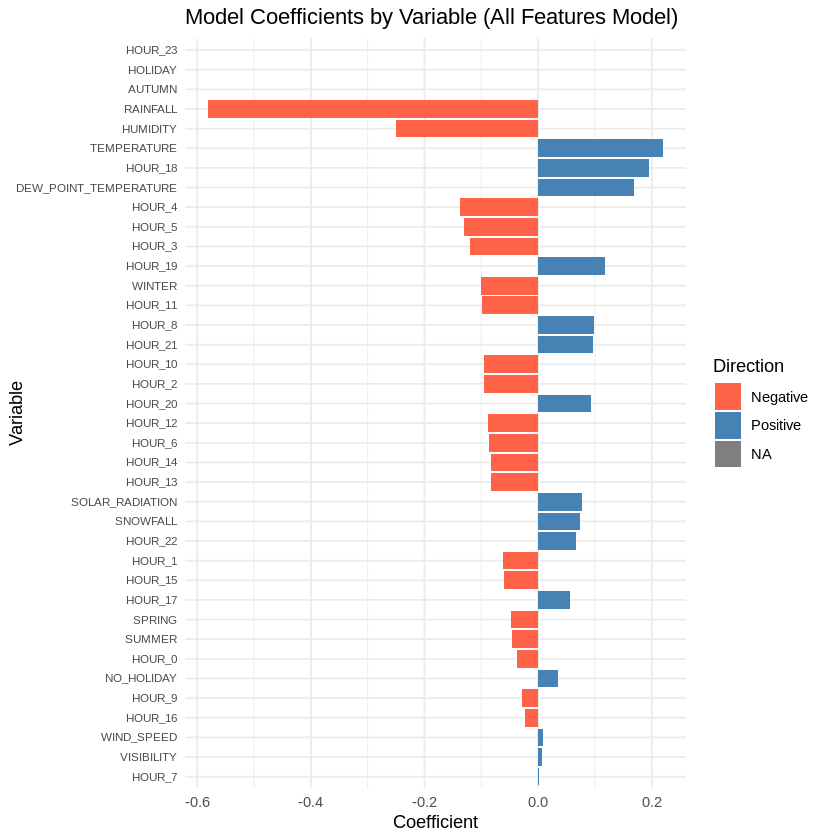

In [16]:
coef_df <- tibble(
  variable    = names(lm_model_all$fit$coefficients),
  coefficient = lm_model_all$fit$coefficients
) %>%
  filter(variable != "(Intercept)") %>%
  mutate(abs_coef = abs(coefficient)) %>%
  arrange(desc(abs_coef))

ggplot(coef_df, aes(x = reorder(variable, abs_coef), y = coefficient)) +
  geom_bar(stat = "identity", aes(fill = coefficient > 0)) +
  scale_fill_manual(values = c("TRUE" = "steelblue", "FALSE" = "tomato"),
                    labels = c("Negative", "Positive"),
                    name   = "Direction") +
  coord_flip() +
  labs(
    title = "Model Coefficients by Variable (All Features Model)",
    x     = "Variable",
    y     = "Coefficient"
  ) +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 7))

## **Polynomial Terms**

Linear models assume a straight-line relationship between each predictor
and the outcome. In reality, some relationships curve. We use the coefficient
chart from the baseline model alongside the EDA scatter plots to guide which
variables deserve higher-degree polynomial terms.

`TEMPERATURE` shows the clearest non-linear curve in the EDA, with demand
rising through spring, peaking in summer, and falling again in winter, so it
receives the highest degree. `HUMIDITY`, `RAINFALL`, and `DEW_POINT_TEMPERATURE`
all showed strong coefficients in the baseline model, with `RAINFALL` being the
largest of any weather variable. These three receive degree 4 terms to capture
threshold-style effects where small changes at certain levels have outsized
impact on demand. The remaining variables had weaker coefficients and no strong
visual evidence of curvature, so degree 2 is sufficient.

The plot below shows how higher-degree polynomials track the temperature-demand
relationship more closely than a straight line.

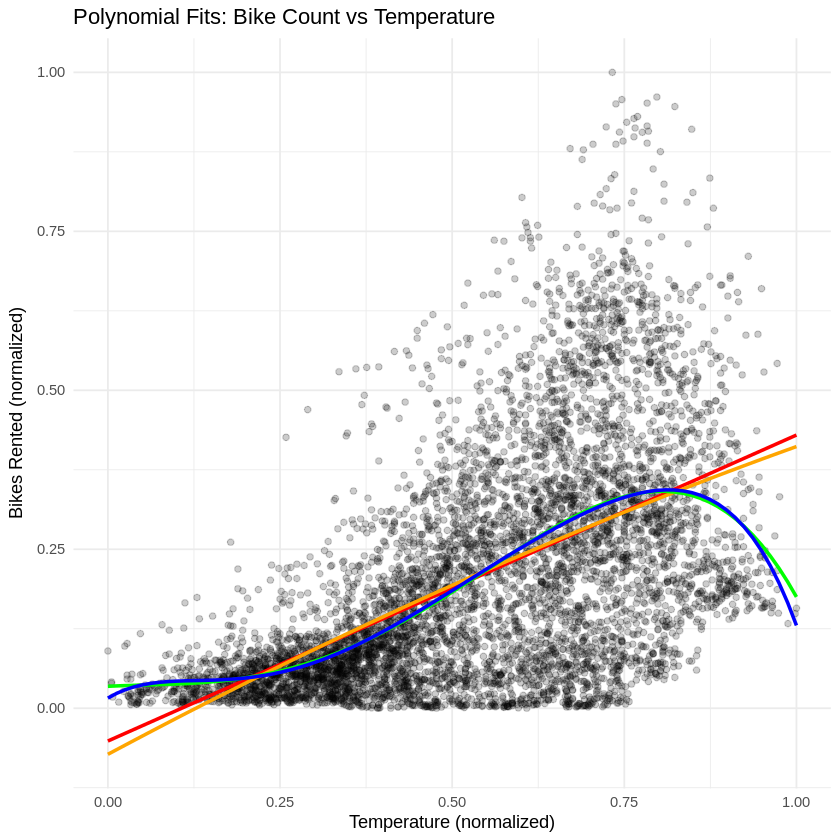

In [17]:
ggplot(train_data, aes(x = TEMPERATURE, y = RENTED_BIKE_COUNT)) +
  geom_point(alpha = 0.2) +
  geom_smooth(method = "lm", formula = y ~ x,          colour = "red",    se = FALSE) +
  geom_smooth(method = "lm", formula = y ~ poly(x, 2), colour = "orange", se = FALSE) +
  geom_smooth(method = "lm", formula = y ~ poly(x, 4), colour = "green",  se = FALSE) +
  geom_smooth(method = "lm", formula = y ~ poly(x, 6), colour = "blue",   se = FALSE) +
  labs(
    title = "Polynomial Fits: Bike Count vs Temperature",
    x     = "Temperature (normalized)",
    y     = "Bikes Rented (normalized)"
  ) +
  theme_minimal()

In [18]:
lm_poly <- lm_spec %>%
  fit(
    RENTED_BIKE_COUNT ~ poly(TEMPERATURE, 6) + poly(HUMIDITY, 4) +
      poly(WIND_SPEED, 2) + poly(VISIBILITY, 2) +
      poly(DEW_POINT_TEMPERATURE, 4) + poly(SOLAR_RADIATION, 2) +
      poly(RAINFALL, 4) + poly(SNOWFALL, 2) +
      HOLIDAY + NO_HOLIDAY +
      WINTER + SPRING + SUMMER + AUTUMN +
      HOUR_0 + HOUR_1 + HOUR_2 + HOUR_3 + HOUR_4 + HOUR_5 +
      HOUR_6 + HOUR_7 + HOUR_8 + HOUR_9 + HOUR_10 + HOUR_11 +
      HOUR_12 + HOUR_13 + HOUR_14 + HOUR_15 + HOUR_16 + HOUR_17 +
      HOUR_18 + HOUR_19 + HOUR_20 + HOUR_21 + HOUR_22 + HOUR_23,
    data = train_data
  )

summary(lm_poly$fit)

all_results[["poly"]] <- evaluate_model(lm_poly, "Polynomial", test_data)


Call:
stats::lm(formula = RENTED_BIKE_COUNT ~ poly(TEMPERATURE, 6) + 
    poly(HUMIDITY, 4) + poly(WIND_SPEED, 2) + poly(VISIBILITY, 
    2) + poly(DEW_POINT_TEMPERATURE, 4) + poly(SOLAR_RADIATION, 
    2) + poly(RAINFALL, 4) + poly(SNOWFALL, 2) + HOLIDAY + NO_HOLIDAY + 
    WINTER + SPRING + SUMMER + AUTUMN + HOUR_0 + HOUR_1 + HOUR_2 + 
    HOUR_3 + HOUR_4 + HOUR_5 + HOUR_6 + HOUR_7 + HOUR_8 + HOUR_9 + 
    HOUR_10 + HOUR_11 + HOUR_12 + HOUR_13 + HOUR_14 + HOUR_15 + 
    HOUR_16 + HOUR_17 + HOUR_18 + HOUR_19 + HOUR_20 + HOUR_21 + 
    HOUR_22 + HOUR_23, data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.49221 -0.05525  0.00164  0.05179  0.39527 

Coefficients: (3 not defined because of singularities)
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      0.272066   0.006563  41.453  < 2e-16 ***
poly(TEMPERATURE, 6)1           10.332846   1.226947   8.422  < 2e-16 ***
poly(TEMPERATURE, 6)2            2.392329  

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `prediction = pmax(0, predict(model, test_data)$.pred)`.
Caused by warning in `predict.lm()`:
! prediction from rank-deficient fit; consider predict(., rankdeficient="NA")”


Polynomial - R2: 0.768  RMSE: 0.0862 


## **Interaction Terms**

Sometimes the effect of one variable depends on the value of another.
A warm summer evening drives far more rentals than the same temperature
on a winter morning. Interaction terms let the model learn these combined
effects rather than treating each variable in isolation.

Here we add interactions between temperature and each season, and between
humidity and the seasons where precipitation has the most impact.

In [19]:
lm_interact <- lm_spec %>%
  fit(
    RENTED_BIKE_COUNT ~ poly(TEMPERATURE, 6) + poly(HUMIDITY, 4) +
      poly(WIND_SPEED, 2) + poly(VISIBILITY, 2) +
      poly(DEW_POINT_TEMPERATURE, 4) + poly(SOLAR_RADIATION, 2) +
      poly(RAINFALL, 4) + poly(SNOWFALL, 2) +
      HOLIDAY + NO_HOLIDAY +
      WINTER + SPRING + SUMMER + AUTUMN +
      HOUR_0 + HOUR_1 + HOUR_2 + HOUR_3 + HOUR_4 + HOUR_5 +
      HOUR_6 + HOUR_7 + HOUR_8 + HOUR_9 + HOUR_10 + HOUR_11 +
      HOUR_12 + HOUR_13 + HOUR_14 + HOUR_15 + HOUR_16 + HOUR_17 +
      HOUR_18 + HOUR_19 + HOUR_20 + HOUR_21 + HOUR_22 + HOUR_23 +
      TEMPERATURE:WINTER + TEMPERATURE:SPRING +
      TEMPERATURE:SUMMER + TEMPERATURE:AUTUMN +
      HUMIDITY:WINTER + HUMIDITY:SUMMER,
    data = train_data
  )

all_results[["interact"]] <- evaluate_model(lm_interact, "Interactions", test_data)

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `prediction = pmax(0, predict(model, test_data)$.pred)`.
Caused by warning in `predict.lm()`:
! prediction from rank-deficient fit; consider predict(., rankdeficient="NA")”


Interactions - R2: 0.7712  RMSE: 0.0857 


## **Hyperparameter Tuning**

Unlike ordinary least squares models, glmnet has two hyperparameters that
must be set before training rather than learned from the data. The first,
`penalty`, controls how aggressively the model shrinks coefficients toward
zero. The second, `mixture`, determines the blend between Ridge and Lasso
regularization, and is fixed by definition for each variant: 0 for Ridge,
1 for Lasso, and 0.5 for Elastic Net.

Rather than guessing a value for `penalty`, we use 5-fold cross-validation
to search across 20 candidate values and select the one that minimizes RMSE
on held-out data. This tuned value is then applied consistently across all
three glmnet variants.

In [20]:
glmnet_formula <- RENTED_BIKE_COUNT ~ poly(TEMPERATURE, 6) + poly(HUMIDITY, 4) +
  poly(WIND_SPEED, 2) + poly(VISIBILITY, 2) +
  poly(DEW_POINT_TEMPERATURE, 4) + poly(SOLAR_RADIATION, 2) +
  poly(RAINFALL, 4) + poly(SNOWFALL, 2) +
  HOLIDAY + NO_HOLIDAY +
  WINTER + SPRING + SUMMER + AUTUMN +
  HOUR_0 + HOUR_1 + HOUR_2 + HOUR_3 + HOUR_4 + HOUR_5 +
  HOUR_6 + HOUR_7 + HOUR_8 + HOUR_9 + HOUR_10 + HOUR_11 +
  HOUR_12 + HOUR_13 + HOUR_14 + HOUR_15 + HOUR_16 + HOUR_17 +
  HOUR_18 + HOUR_19 + HOUR_20 + HOUR_21 + HOUR_22 + HOUR_23 +
  TEMPERATURE:WINTER + TEMPERATURE:SPRING +
  TEMPERATURE:SUMMER + TEMPERATURE:AUTUMN +
  HUMIDITY:WINTER + HUMIDITY:SUMMER

tune_spec <- linear_reg(penalty = tune(), mixture = 0.5) %>%
  set_engine("glmnet") %>%
  set_mode("regression")

cv_folds      <- vfold_cv(train_data, v = 5)
penalty_grid  <- grid_regular(penalty(), levels = 20)

tune_results <- tune_grid(
  tune_spec,
  glmnet_formula,
  resamples = cv_folds,
  grid      = penalty_grid
)

best_penalty <- tune_results %>% select_best(metric = "rmse")
cat("Best penalty:", best_penalty$penalty, "\n")

→ A | warning: A correlation computation is required, but `estimate` is constant and has 0
               standard deviation, resulting in a divide by 0 error. `NA` will be returned.

There were issues with some computations   A: x2

There were issues with some computations   A: x4

There were issues with some computations   A: x10





Best penalty: 6.158482e-05 


## **Regularization with glmnet**

With the optimal penalty in hand, we fit all three regularization variants
and add them to the results store.

- **Ridge** shrinks all coefficients but keeps every variable in the model
- **Lasso** can shrink coefficients all the way to zero, effectively removing variables
- **Elastic Net** blends both approaches, offering a balance between the two

In [21]:
fit_glmnet <- function(mixture, label) {
  spec <- linear_reg(penalty = best_penalty$penalty, mixture = mixture) %>%
    set_engine("glmnet") %>%
    set_mode("regression")
  spec %>% fit(glmnet_formula, data = train_data)
}

model_ridge       <- fit_glmnet(0,   "Ridge")
model_lasso       <- fit_glmnet(1,   "Lasso")
model_elastic_net <- fit_glmnet(0.5, "Elastic Net")

all_results[["ridge"]]       <- evaluate_model(model_ridge,       "Ridge",       test_data)
all_results[["lasso"]]       <- evaluate_model(model_lasso,       "Lasso",       test_data)
all_results[["elastic_net"]] <- evaluate_model(model_elastic_net, "Elastic Net", test_data)

Ridge - R2: 0.7672  RMSE: 0.087 
Lasso - R2: 0.7706  RMSE: 0.0858 
Elastic Net - R2: 0.7705  RMSE: 0.0858 


## **Model Comparison**

All six models are ranked side by side by RMSE. A lower RMSE means the
predictions are closer to the actual counts on average. R-squared tells
us what proportion of the variation in demand the model explains, where
higher is better. The winning model is identified automatically and used
in the diagnostic plot below.

In [22]:
model_comparison <- bind_rows(
  lapply(all_results, function(r) tibble(model = r$label, R2 = r$r2, RMSE = r$rmse))
) %>%
  arrange(RMSE)

print(model_comparison)

best_model_label <- model_comparison$model[1]
cat("\nBest model:", best_model_label, "\n")

# A tibble: 7 × 3
  model           R2   RMSE
  <chr>        <dbl>  <dbl>
1 Interactions 0.771 0.0857
2 Lasso        0.771 0.0858
3 Elastic Net  0.771 0.0858
4 Polynomial   0.768 0.0862
5 Ridge        0.767 0.0870
6 All Features 0.689 0.0999
7 Weather Only 0.441 0.133 

Best model: Interactions 


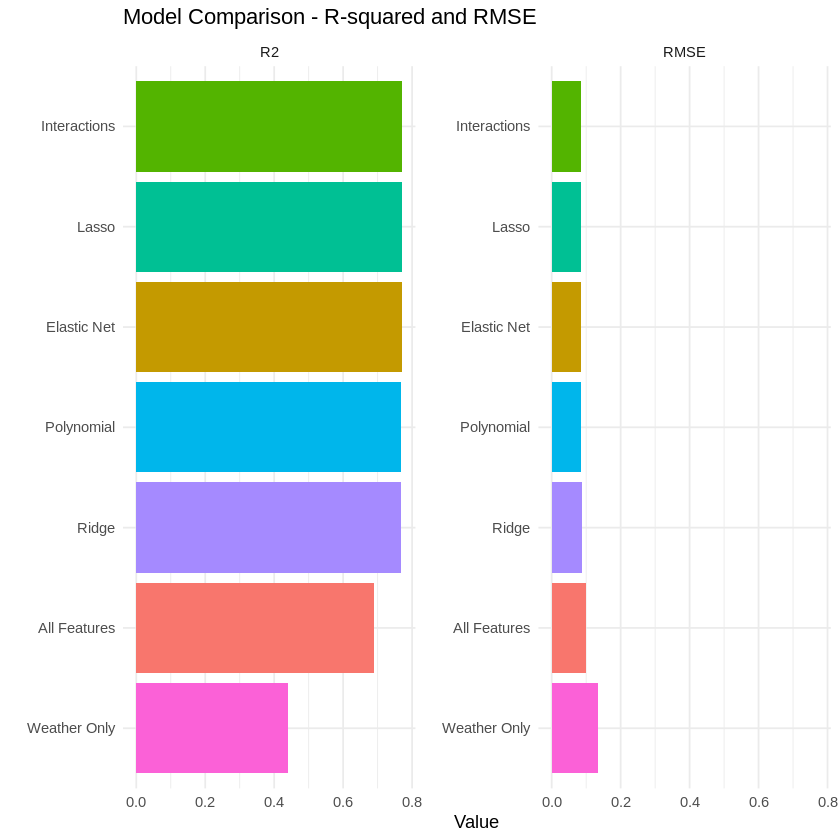

In [23]:
model_comparison_long <- model_comparison %>%
  pivot_longer(cols = c(R2, RMSE), names_to = "metric", values_to = "value")

ggplot(model_comparison_long,
       aes(x = reorder(model, value), y = value, fill = model)) +
  geom_bar(stat = "identity") +
  facet_wrap(~ metric, scales = "free_y") +
  coord_flip() +
  labs(
    title = "Model Comparison - R-squared and RMSE",
    x     = NULL,
    y     = "Value"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

## **Residual Diagnostics - Q-Q Plot**

A Q-Q plot compares how the distribution of predictions from the best model
lines up against the actual values. If the model were perfect, the two
distributions would be identical and the points would form a straight
diagonal line. Deviations from that line show where the model struggles,
typically at the extremes of demand.

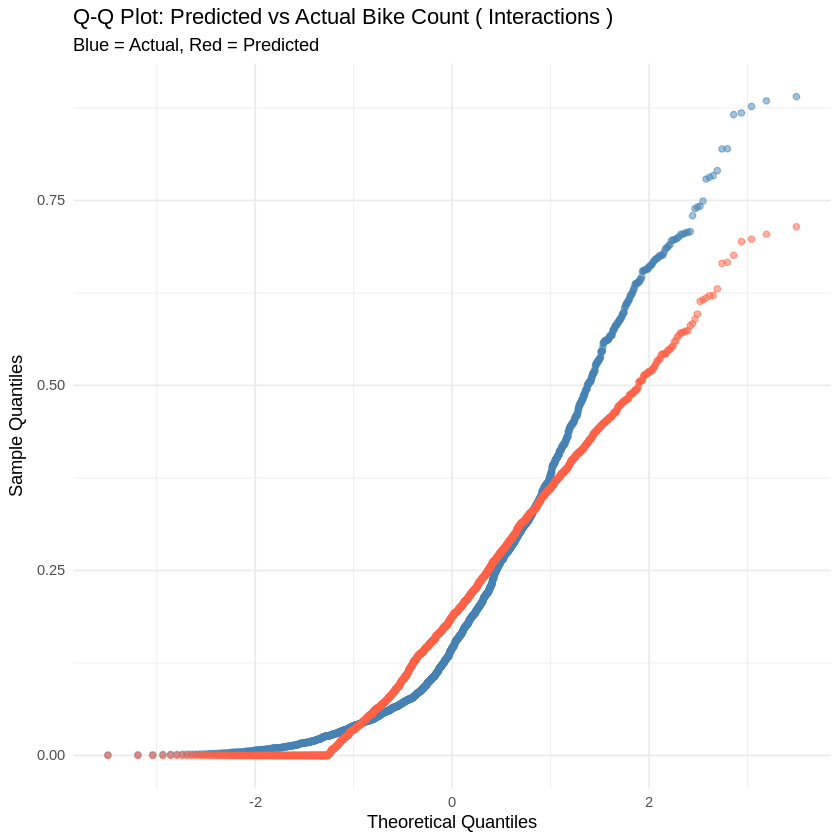

In [24]:
best_key <- names(all_results)[
  which.min(sapply(all_results, function(r) r$rmse))
]
best_predictions <- all_results[[best_key]]$predictions

ggplot(best_predictions) +
  stat_qq(aes(sample = truth),      colour = "steelblue", alpha = 0.5) +
  stat_qq(aes(sample = prediction), colour = "tomato",    alpha = 0.5) +
  labs(
    title    = paste("Q-Q Plot: Predicted vs Actual Bike Count (", best_model_label, ")"),
    subtitle = "Blue = Actual, Red = Predicted",
    x        = "Theoretical Quantiles",
    y        = "Sample Quantiles"
  ) +
  theme_minimal()

**Observations**

The Interactions model was selected as the best performer, though in practice
the top four models (Interactions, Lasso, Elastic Net, and Polynomial) are
essentially tied to four decimal places in both R2 and RMSE. This suggests
that the polynomial terms did most of the heavy lifting, and that the
additional complexity of interaction terms and regularization added
diminishing returns on a dataset of this size.

**What the Q-Q plot shows:**

In the middle range of demand, the blue (actual) and red (predicted) curves
track each other closely. This is the model working well: for typical hourly
demand levels, predictions are reliable.

The left tail tells a different story. The red curve sits flat at zero for
an extended stretch while the actual values rise gradually above it. This
happens because linear regression can produce negative predictions, which
get floored to zero. The result is a model that cannot distinguish between
"very low demand" and "zero demand", treating both as the same thing.

The right tail is where the model struggles most visibly. The blue curve
extends significantly higher than the red, meaning the model consistently
underestimates peak demand hours. This is a known limitation of ordinary
least squares: it optimizes for the average case and tends to pull
predictions toward the mean, systematically missing the extremes.

**Why this happens:**

Both issues stem from a fundamental mismatch between linear regression and
count data. Bike rental counts are non-negative, right-skewed, and driven
by rare high-demand events that a linear model has no special mechanism to
capture. The model is doing a reasonable job given these constraints, but
it is working against its own assumptions.

**What R2 and RMSE tell us:**

An R2 of 0.771 means the model explains about 77% of the variation in hourly
demand, which is a strong result for a linear model on real-world data. The
normalized RMSE of 0.086 translates to a mean prediction error of roughly
8.6% of the maximum demand value. Both figures comfortably exceed the course
benchmarks of R2 > 0.72 and RMSE < 0.13.

**What a production pipeline would do differently:**

Several approaches could address the limitations observed here. Log
transforming the response variable before modeling would naturally prevent
negative predictions and typically improves fit for right-skewed count data,
with predictions exponentiated back to the original scale after inference.
Poisson or negative binomial regression builds the non-negative constraint
directly into the model structure rather than clipping after the fact, and
is the standard professional choice for count data.

For the right tail specifically, gradient boosting models such as XGBoost
or LightGBM are substantially better at capturing extreme values, because
they iteratively correct prediction errors rather than fitting a single
global surface. Random forests offer similar advantages. These approaches
would be the natural next step in a production forecasting context, where
accurate prediction of peak demand hours is likely the most operationally
important requirement.